# Tuning and Model Evaluation

## Used libraries

In [ ]:
import seaborn as sns
import numpy as np
import pandas as pd
import optuna

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV, KFold
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif, SelectFromModel, f_classif

## Loading data

In [ ]:
train = pd.read_csv('../train_extended.csv', index_col='ID') 
test = pd.read_csv('../test_extended.csv', index_col='ID')
x_train, y_train = train.drop('RET', axis=1), train['RET']

In [ ]:
# convert categorical columns to category type
categorical_features = ['STOCK','INDUSTRY','INDUSTRY_GROUP','SECTOR','SUB_INDUSTRY']
for col in categorical_features:
    x_train[col] = x_train[col].astype('category')
    test[col] = test[col].astype('category')


## Feature pre-selection

Below the differents selection of feature done on the ``notebook_feature_selection.ipynb``

In [ ]:
# Select the best feature by importing selectedFeaturesXGB.csv and selectedFeaturesRF.csv
selectedFeaturesXGB = pd.read_csv('../selectedFeaturesXGB.csv')
selectedFeaturesRF = pd.read_csv('../selectedFeaturesRF.csv')
# lets take the union of the two selected features
selectedFeaturesTrees = list(set(selectedFeaturesXGB['0']).union(set(selectedFeaturesRF['0'])))

# Select the best feature by importing scores_f_classif.csv and scores_mutual_info.csv
scores_f = pd.read_csv('../scores_f_classif.csv')
scores_mutual_info = pd.read_csv('../scores_mutual_info.csv')
# lets take the 100 best features from the scores_f and scores_mutual_info
selectedFeaturesF = list(scores_f['feature'][:100])
selectedFeaturesMI = list(scores_mutual_info['feature'][:100])

Below my cherry-pick selection of features based on multiple hours of cooking (works better than the previous feature selection)

In [136]:
# drop all the features that contain some of the following substrings
base_features = [x for x in test.columns if not any(substring in x for substring in ['INDUSTRY', 'STOCK', 'min', 'max', 'kurt', 'skew', 'median'])]

ret_cols = [f'RET_{i}' for i in range(1, 6)]
ret_drop_cols = [f'RET_{i}' for i in range(6, 21)]
vol_cols = [f'VOLUME_{i}' for i in range(1, 6)]
vol_drop_cols = [f'VOLUME_{i}' for i in range(6, 21)]

categorical_features = ['SECTOR', 'INDUSTRY_GROUP', 'INDUSTRY']
SECTOR_DATE_features = [ feature for feature in base_features if 'SECTOR_DATE_' in feature]
WEEKLY_features = [ feature for feature in base_features if 'WEEK' in feature]
technical_indicators_features = [ feature for feature in base_features if any(substring in feature for substring in ['MA', 'RSI', 'MOMENTUM', 'VW', 'Corr', 'SURGE'])]

benchmark_features = list(set(ret_cols + vol_cols + categorical_features + SECTOR_DATE_features ))
other_features = list(set(base_features) -set(['DATE']) - set(benchmark_features) - set(technical_indicators_features) - set(WEEKLY_features) - set(ret_drop_cols) - set(vol_drop_cols))

Here I'm testing various combinations of subsets to find the best recipe.

In [141]:
features = benchmark_features + other_features
len(features)

92

In [ ]:
# optuna hyperparameter optimization

def objective(trial):
    # Define the hyperparameters to optimize
    clf_iterations = trial.suggest_int('iterations', 100, 1000)
    clf_depth = trial.suggest_int('depth', 4, 10)
    # Define the model
    clf =  CatBoostClassifier(iterations = clf_iterations, depth= clf_depth,early_stopping_rounds=100, verbose=0, task_type='GPU', cat_features=categorical_features)
    # Define the score
    score = cross_val_score(clf, x_train[features], y_train, cv=4, scoring='accuracy').mean()
    return score

# Create a study object and optimize the objective function
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

# Print the best set of hyperparameters
print('Best hyperparameters: ', study.best_params)
# Print the corresponding performance
print('Best performance: ', study.best_value)

## Model and local score

A Random Forest (RF) model is chosen for the Benchmark. We consider a large number of tree with a quiet small depth. The missing values are simply filled with 0. A KFold is done on the dates (using `DATE`) for a local scoring of the model. 

**Ideas of improvements**: Tune the RF hyperparameters, deal with the missing values, change the features, consider another model, ...

In [ ]:
X_train = train[features]

# A quiet large number of trees with low depth to prevent overfits

train_dates = train['DATE'].unique()
test_dates = test['DATE'].unique()

n_splits = 4
scores = []
models = []
base_model = CatBoostClassifier(depth=6, iterations=900,  early_stopping_rounds=100,  verbose=0, task_type='GPU', cat_features=categorical_features)

splits = KFold(n_splits=n_splits, random_state=0,
               shuffle=True).split(train_dates)
    
for i, (local_train_dates_ids, local_test_dates_ids) in enumerate(splits):
    local_train_dates = train_dates[local_train_dates_ids]
    local_test_dates = train_dates[local_test_dates_ids]

    local_train_ids = train['DATE'].isin(local_train_dates)
    local_test_ids = train['DATE'].isin(local_test_dates)

    X_local_train = X_train.loc[local_train_ids]
    y_local_train = y_train.loc[local_train_ids]
    X_local_test = X_train.loc[local_test_ids]
    y_local_test = y_train.loc[local_test_ids]

    X_local_train = X_local_train.fillna(0)
    X_local_test = X_local_test.fillna(0)

    model = base_model
    model.fit(X_local_train, y_local_train)
  
    y_local_pred = model.predict_proba(X_local_test)[:, 1]
    
    sub = train.loc[local_test_ids].copy()
    sub['pred'] = y_local_pred
    y_local_pred = sub.groupby('DATE')['pred'].transform(lambda x: x > x.median()).values

    models.append(model)
    score = accuracy_score(y_local_test, y_local_pred)
    scores.append(score)
    print(f"Fold {i+1} - Accuracy: {score* 100:.2f}%")

mean = np.mean(scores)*100
std = np.std(scores)*100
u = (mean + std)
l = (mean - std)
print(f'Accuracy: {mean:.2f}% [{l:.2f} ; {u:.2f}] (+- {std:.2f})')

Fold 1 - Accuracy: 51.05%
Fold 2 - Accuracy: 52.46%


In [ ]:
# cross validation score with predict built-in method to compare with the previous prediction method
score = cross_val_score(base_model, X_train, y_train, cv=4, scoring='accuracy', n_jobs=-1, verbose=3)

print("Cross-validation score with predict built-in method")
for i in range(len(score)):
    print(f'Fold {i+1} - Accuracy: {score[i]*100:.2f}%')
print(f'Accuracy: {np.mean(score)*100:.2f}% (+- {np.std(score)*100:.2f})')

<Axes: >

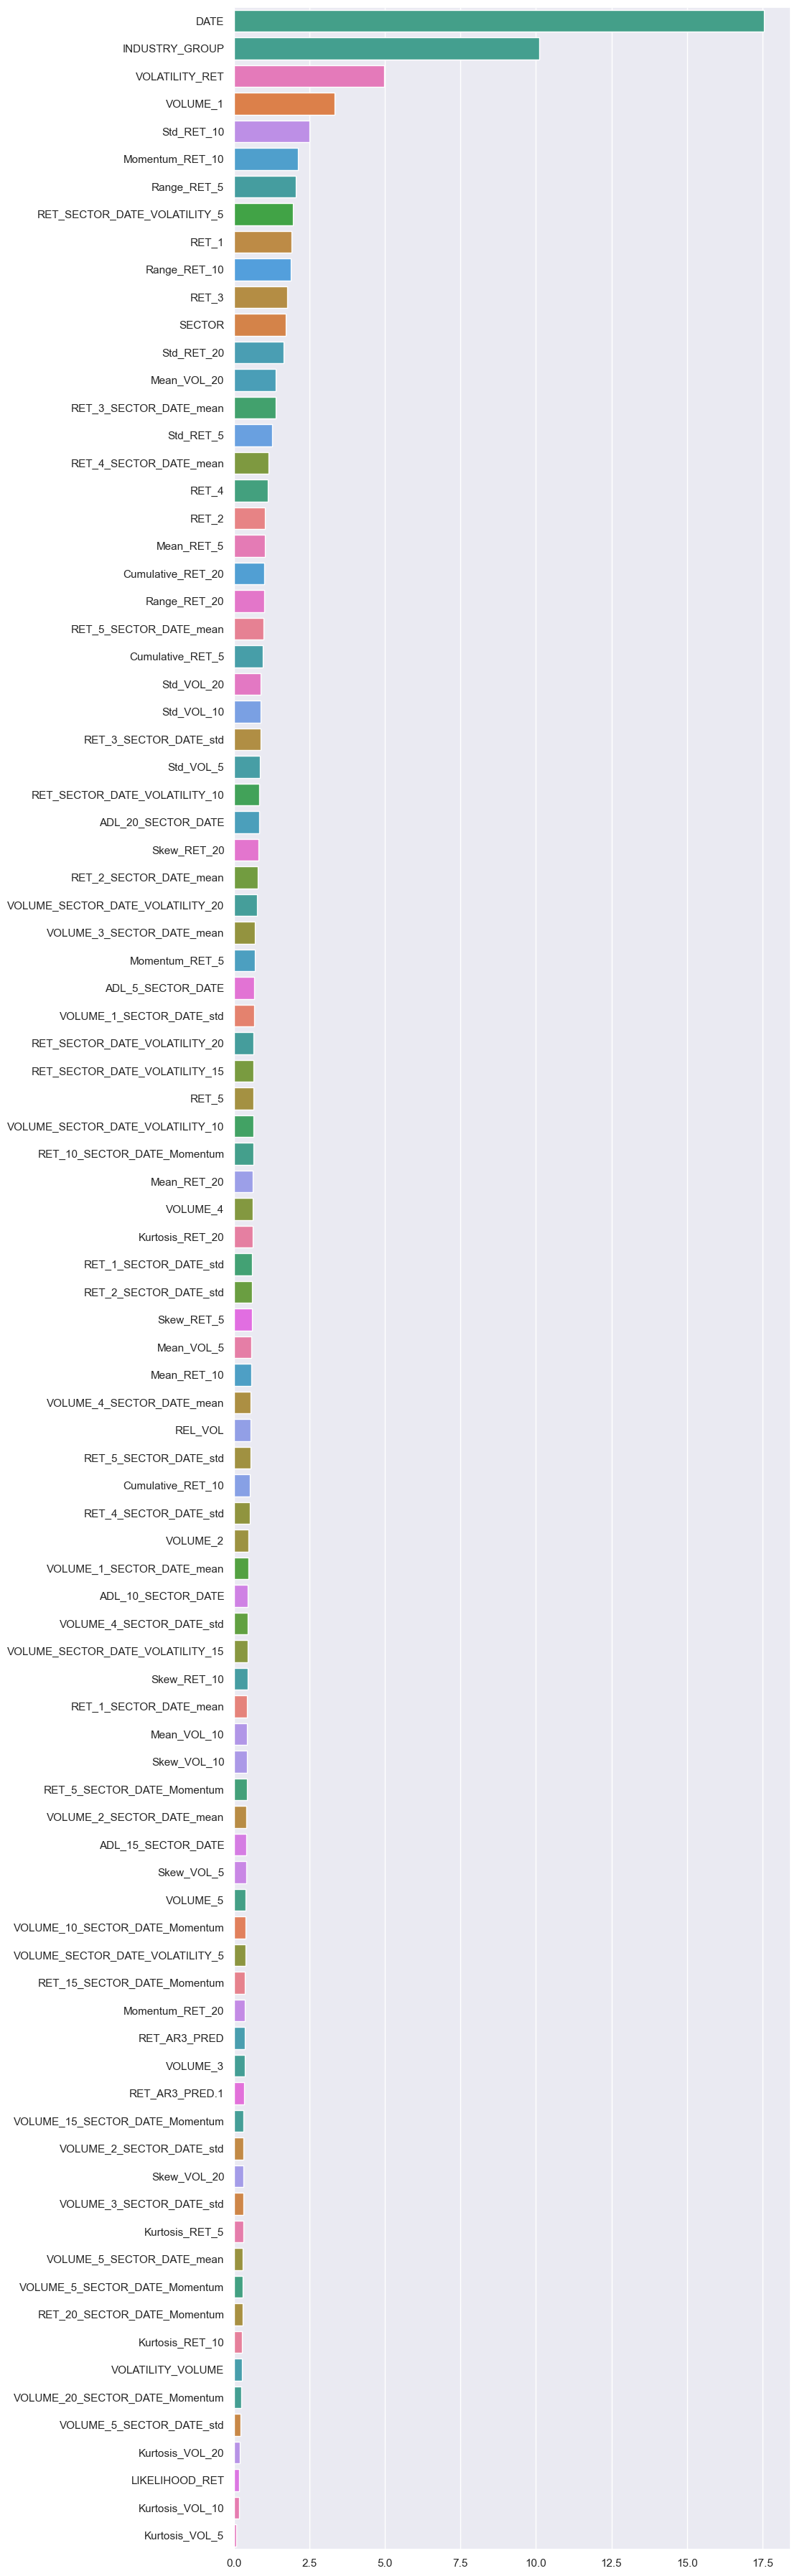

In [ ]:
feature_importances = pd.DataFrame([model.feature_importances_ for model in models], columns=features)

sns.set(rc={'figure.figsize':(10,len(features)//2)})
sns.barplot(data=feature_importances, orient='h', order=feature_importances.mean().sort_values(ascending=False).index )

## Generate the submission

The same parameters of the RF model are considered. With that we build a new RF model on the entire `train` dataset. The predictions are saved in a `.csv` file.

In [ ]:
target = 'RET'
X_test = test[features]

model = base_model
model.fit(X_train, y_train)
y_pred = model.predict_proba(X_test)[:, 1]

sub = test.copy()
sub['pred'] = y_pred
y_pred = sub.groupby('DATE')['pred'].transform(
    lambda x: x > x.median()).values

submission = pd.Series(y_pred)
submission.index = test.index
submission.name = target

submission.to_csv('submission.csv', index=True, header=True)

## Draft Zone

### Defining our ML Pipeline and the GridSearchCV procedure
- Throug a GridSearchCV we aim to compare the performance of different Imputations methods and Feature Selections
- For that we create a pipeline to embbed all the successive steps of the data transformation in one estimator
- Warning to use Catboost in a pipeline : 
    - https://medium.com/analytics-vidhya/combining-scikit-learn-pipelines-with-catboost-and-dask-part-2-9240242966a7
    - https://stackoverflow.com/questions/56742441/



In [ ]:

model = Pipeline([
    ('feature_selection', 'passthrough'),
    ('classify', 'passthrough')
])

# Define the parameter grid for GridSearchCV
param_grid = [
    {
        'feature_selection': [SelectFromModel(RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1))],
        'feature_selection__max_features': [75],
        'classify': [RandomForestClassifier(n_estimators=500, max_depth=8, n_jobs=-1), 
                    CatBoostClassifier(depth=6, iterations=1000,  early_stopping_rounds=100, task_type="GPU", devices='0', verbose=0)]
    },

    {
        'feature_selection': [SelectFromModel(CatBoostClassifier(depth=8, iterations=1000,  early_stopping_rounds=50, task_type="GPU", devices='0', verbose=0))],
        'feature_selection__max_features': [75],
        'classify': [RandomForestClassifier(n_estimators=500, max_depth=8, n_jobs=-1), 
                    CatBoostClassifier(depth=6, iterations=1000,  early_stopping_rounds=100, task_type="GPU", devices='0', verbose=0)]
    },
    
    {
        'feature_selection': [SelectKBest()],
        'feature_selection__score_func': [mutual_info_classif, f_classif],
        'feature_selection__k': [75],
        'classify': [RandomForestClassifier(n_estimators=500, max_depth=8, n_jobs=-1), 
                    CatBoostClassifier(depth=8, iterations=1000,  early_stopping_rounds=100, task_type="GPU", devices='0', verbose=0)],
    }
]

# define the GridSearchCV
grid = GridSearchCV(model, param_grid, cv=3, scoring='accuracy', verbose=3, n_jobs=1, error_score='raise')

# fit the GridSearchCV
grid.fit(x_train, y_train)

# get the parameters of models sorted by ranked score of accuracy
results = pd.DataFrame(grid.cv_results_)
results.sort_values(by='rank_test_score', inplace=True)
results